# Arboles de decision y Naive Bayes sobre el dataset Iris

**Actividad 2 - Arboles** | Alferry | 2 de julio de 2026

Este cuaderno aplica y compara dos algoritmos de clasificacion sobre el clasico
dataset **Iris** (150 observaciones, 4 atributos numericos, 3 especies):

1. **Arbol de decision (ID3 / C4.5)** usando ganancia de informacion (entropia).
2. **Naive Bayes Gaussiano**.

Se incluyen: analisis exploratorio, entrenamiento, visualizacion del arbol,
matrices de confusion y una comparacion final de resultados.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

sns.set_style("whitegrid")

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=["target"])
print(df.shape)
df.head()


(150, 5)


## 1. Analisis exploratorio

Revisamos estadisticas descriptivas y la relacion entre atributos por especie.


In [4]:
print(df.describe())
print()
print(df["species"].value_counts())


       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000          1.300000
75%             6.400000          3.300000           5.100000          1.800000
max             7.900000          4.400000           6.900000          2.500000

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


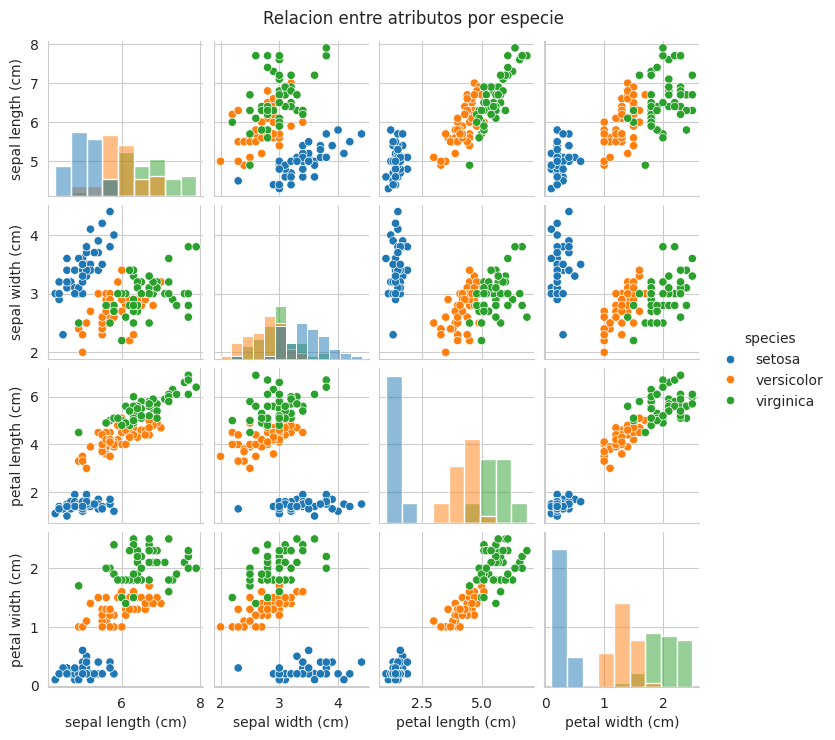

In [5]:
sns.pairplot(df, hue="species", diag_kind="hist", height=1.8)
plt.suptitle("Relacion entre atributos por especie", y=1.02)
plt.show()


## 2. Arbol de decision (criterio de entropia = ID3 / C4.5)

Se entrena un `DecisionTreeClassifier` con `criterion="entropy"`, el mismo
criterio de ganancia de informacion que usa ID3, pero permitiendo atributos
numericos continuos (como C4.5 / J48 en Weka), sin limite de profundidad.


In [7]:
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree.fit(X_train, y_train)

print(export_text(tree, feature_names=list(X.columns)))


|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- petal width (cm) <= 1.85
|   |   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |   |--- class: versicolor
|   |   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |   |   |--- class: versicolor
|   |   |   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |   |   |--- class: virginica
|   |   |   |--- petal width (cm) >  1.85
|   |   |   |   |--- class: virginica
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: virginica



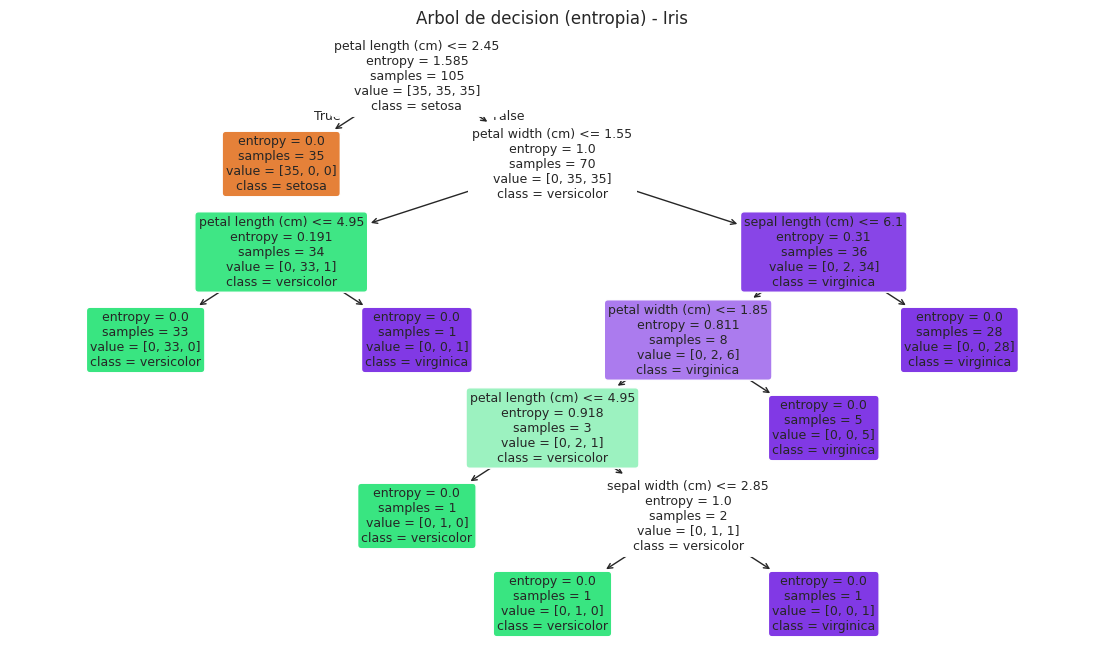

In [8]:
plt.figure(figsize=(14, 8))
plot_tree(tree, feature_names=list(X.columns), class_names=tree.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Arbol de decision (entropia) - Iris")
plt.show()


Accuracy (arbol de decision): 0.8889 (40/45)


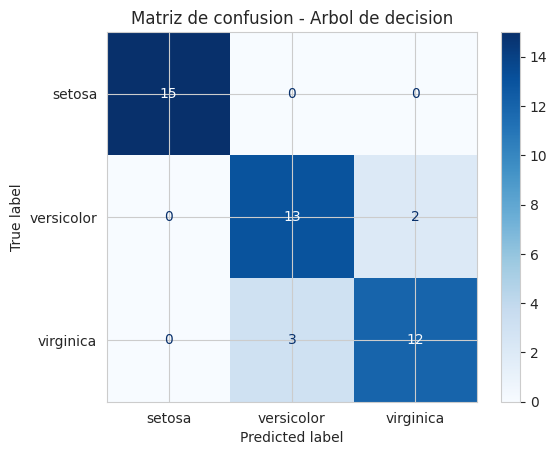

In [9]:
y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Accuracy (arbol de decision): {acc_tree:.4f} ({int(acc_tree*len(y_test))}/{len(y_test)})")

cm_tree = confusion_matrix(y_test, y_pred_tree, labels=tree.classes_)
disp = ConfusionMatrixDisplay(cm_tree, display_labels=tree.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusion - Arbol de decision")
plt.show()


## 3. Naive Bayes Gaussiano

Se entrena un clasificador `GaussianNB`, que asume que cada atributo sigue una
distribucion normal dentro de cada clase (la formulacion continua de Naive
Bayes, equivalente a `e1071::naiveBayes` en R para datos numericos).


Accuracy (Naive Bayes): 0.9111 (41/45)


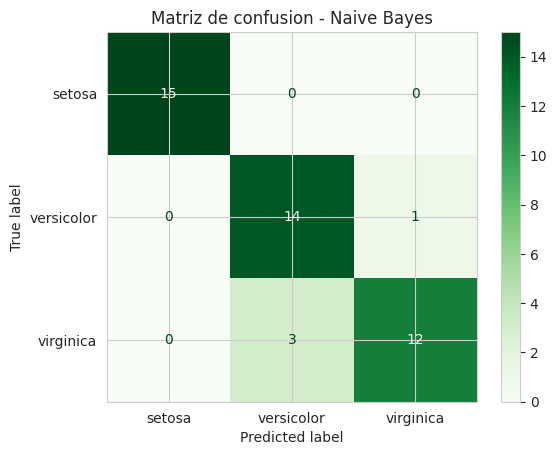

In [11]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy (Naive Bayes): {acc_nb:.4f} ({int(acc_nb*len(y_test))}/{len(y_test)})")

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
disp = ConfusionMatrixDisplay(cm_nb, display_labels=nb.classes_)
disp.plot(cmap="Greens", values_format="d")
plt.title("Matriz de confusion - Naive Bayes")
plt.show()


## 4. Comparacion de resultados


In [13]:
comparacion = pd.DataFrame({
    "Modelo": ["Arbol de decision (entropia)", "Naive Bayes (Gaussiano)"],
    "Accuracy (test 30%)": [acc_tree, acc_nb],
})
comparacion


## 5. Conclusiones

- Ambos modelos alcanzan una exactitud alta sobre Iris, confirmando que es un
  dataset facilmente separable.
- El atributo **ancho de petalo** (`petal width`) resulta el mas discriminante
  en el arbol de decision, igual que en el analisis ID3 con datos
  discretizados (punto 2) y en J48 sobre Weka (punto 4).
- En ambos modelos, la principal fuente de error se concentra entre
  **Iris-versicolor** y **Iris-virginica**, las especies con mayor solapamiento
  en sus atributos.
- Este cuaderno complementa los resultados obtenidos en Excel (ID3 y matriz de
  confusion manual de Naive Bayes) y en los archivos Rmd/HTML (Naive Bayes en
  R para Iris y para el dataset ficticio de la FCI).

---
*Cuaderno generado como parte de la Actividad 2 - Arboles de decision y Naive Bayes.*
